#Beyond Task-Specific Models: A Multi-Task Transformer for Robotic Surgery Skill Assessment
---

### (Multi-task transformer model for predicting M-OSATS scores and surgeon's experience level on the JIGSAWS dataset). Transformer-based model for predicting M-OSATS scores and GRS  

In [ ]:
!pip install fvcore -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
#Imports
from google.colab import drive
import glob
import zipfile
import random
import os
import math
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import re
import pandas as pd
from tabulate import tabulate
import torch.nn as nn
import pickle
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader , Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ParameterGrid
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import get_linear_schedule_with_warmup
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
from scipy.stats import spearmanr
import time
from fvcore.nn import FlopCountAnalysis, parameter_count_table
from torch.nn.attention import sdpa_kernel, SDPBackend


In [ ]:
#Mounting google drive to access data
drive.mount('/content/drive2')

## *JIGSAWS Dataset- Preprocessing*


### Unzipping JIGSAWS files from drive (ONLY ONCE!!)

In [ ]:
#****************************************************************************************
#Unzip data from the google drive folder- for running in laptop we need to change paths
#***********(ONLY RUN FOR THE FIRST TIME)************************************************

ZIP_FILE_PATH = "/content/drive/MyDrive/"  
EXTRACT_PATH = "/content/drive/MyDrive/"

zip_files = glob.glob(os.path.join(ZIP_FILE_PATH, "*.zip"))

#Extract All ZIP Files but Skip Already Extracted Files
print(f"Found {len(zip_files)} ZIP files. Extracting...")
for zip_file in tqdm(zip_files, desc="Processing ZIPs", unit="file"):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        file_list = zip_ref.namelist()  # List of files in ZIP
        for file in tqdm(file_list, desc=f"Extracting {os.path.basename(zip_file)}", unit="file", leave=False):
            extracted_path = os.path.join(EXTRACT_PATH, file)
            #Skip extraction if file already exists
            if os.path.exists(extracted_path):
                continue
            zip_ref.extract(file, EXTRACT_PATH)  # Extract file
    print(f"Finished: {zip_file} -> {EXTRACT_PATH}")

#Check Extracted Files
print("Extracted files:", os.listdir(EXTRACT_PATH))

Found 0 ZIP files. Extracting...


Processing ZIPs: 0file [00:00, ?file/s]

Extracted files: ['Colab Notebooks', '.ipynb_checkpoints', 'Needle_Passing', 'best_params_LOSO.pkl', 'Knot_Tying', 'Experimental_setup', 'best_params_LOTO.pkl', 'best_params_LOUO.pkl', 'Suturing', 'model_LOSO_AT_split_0.pth', 'model_LOSO_AT_split_1.pth', 'model_LOSO_AT_split_2.pth', 'model_LOSO_AT_split_3.pth', 'model_LOSO_AT_split_4.pth', 'model_LOSO_KT_split_0.pth', 'model_LOSO_KT_split_1.pth', 'model_LOSO_KT_split_2.pth', 'model_LOSO_KT_split_3.pth', 'model_LOSO_KT_split_4.pth', 'model_LOSO_NP_split_0.pth', 'model_LOSO_NP_split_1.pth', 'model_LOSO_NP_split_2.pth', 'model_LOSO_NP_split_3.pth', 'model_LOSO_NP_split_4.pth', 'model_LOSO_SU_split_0.pth', 'model_LOSO_SU_split_1.pth', 'model_LOSO_SU_split_2.pth', 'model_LOSO_SU_split_3.pth', 'model_LOSO_SU_split_4.pth', 'info.docx', 'tokensaver.skill', 'complex.skill', 'debug.skill', 'checkpoint.skill', 'diffmode.skill', 'research.skill', 'Transformers_Technical_Details.docx', 'paper.txt', 'paper_reviews.docx', 'ablation_results', 'model_A

### Checking for missing or corrupted files and keep only the valid kinematics files

In [ ]:
#PATHS (ensure that have the same order)
META_FILES_PATHS = [
    "/content/drive/MyDrive/Knot_Tying/meta_file_Knot_Tying.txt",            #KT
    "/content/drive/MyDrive/Needle_Passing/meta_file_Needle_Passing.txt",    #NP
    "/content/drive/MyDrive/Suturing/meta_file_Suturing.txt"                 #SU
]
KINEMATICS_FOLDER_PATHS = [
    "/content/drive/MyDrive/Knot_Tying/kinematics/AllGestures/",             #KT
    "/content/drive/MyDrive/Needle_Passing/kinematics/AllGestures/",         #NP
    "/content/drive/MyDrive/Suturing/kinematics/AllGestures/"                #SU
]
TASKS = ["Knot Tying", "Needle Passing", "Suturing"]

In [ ]:
'''
We have 39 trials of SU, 36 trials from KT and 28 from NP
#1---Knot tying(KT)
#2---Needle passing(NP)
#3---Suturing(SU)

meta_file data  columns
____________________
1:  filename
2:  skill-level self-proclaimed
    E-expert (>100hrs), I-intermediate (10-100hrs), N-novice (<10hrs)
3:  skill-level GRS
4-9: score of each element of modified global rating score, in the order of
	 - Respect for tissue
	 - Suture/needle handling
	 - Time and motion
	 - Flow of operation
	 - Overall performance
	 - Quality of final product
'''
valid_kinematic_files = []
extra_kinematic_files = []

for i in range(3): #For each of the three tasks: 1)Knot tying(KT)   2)Needle passing(NP)  3)Suturing(SU)
  valid_trials = set()
  with open(META_FILES_PATHS[i], "r") as f:
    for line in f:
      if line.strip():  # Check if the line is not empty or just whitespace
        filename = line.split()[0]  # Extract first column (trial name)
        valid_trials.add(filename + ".txt")  # Add ".txt" extension

  kinematic_files = set(os.listdir(KINEMATICS_FOLDER_PATHS[i]))

  common_files = valid_trials.intersection(kinematic_files)
  extra_files = kinematic_files - valid_trials
  valid_kinematic_files.append(sorted(common_files))
  extra_kinematic_files.append(sorted(extra_files))

  print(f"✅ Found {len(common_files)} valid kinematic files for {TASKS[i]} task.")
  if extra_files:
    print(f"⚠️ Extra {len(extra_files)} files (in kinematics folder but NO annotations):")


print("List of valid kinematic files for each task:")
for idx, files in enumerate(valid_kinematic_files):
    print(f"Task {idx+1} / {TASKS[idx]} : {files}")
print("List of extra kinematic files for each task:")
for idx, files in enumerate(extra_kinematic_files):
    print(f"Task {idx+1} / {TASKS[idx]} : {files}")

#Dataset Dictionary per file
valid_files_dict = {
    "Knot Tying": valid_kinematic_files[0],
    "Needle Passing": valid_kinematic_files[1],
    "Suturing": valid_kinematic_files[2]
}


✅ Found 36 valid kinematic files for Knot Tying task.
⚠️ Extra 4 files (in kinematics folder but NO annotations):
✅ Found 28 valid kinematic files for Needle Passing task.
⚠️ Extra 12 files (in kinematics folder but NO annotations):
✅ Found 39 valid kinematic files for Suturing task.
⚠️ Extra 1 files (in kinematics folder but NO annotations):
List of valid kinematic files for each task:
Task 1 / Knot Tying : ['Knot_Tying_B001.txt', 'Knot_Tying_B002.txt', 'Knot_Tying_B003.txt', 'Knot_Tying_B004.txt', 'Knot_Tying_C001.txt', 'Knot_Tying_C002.txt', 'Knot_Tying_C003.txt', 'Knot_Tying_C004.txt', 'Knot_Tying_C005.txt', 'Knot_Tying_D001.txt', 'Knot_Tying_D002.txt', 'Knot_Tying_D003.txt', 'Knot_Tying_D004.txt', 'Knot_Tying_D005.txt', 'Knot_Tying_E001.txt', 'Knot_Tying_E002.txt', 'Knot_Tying_E003.txt', 'Knot_Tying_E004.txt', 'Knot_Tying_E005.txt', 'Knot_Tying_F001.txt', 'Knot_Tying_F002.txt', 'Knot_Tying_F003.txt', 'Knot_Tying_F004.txt', 'Knot_Tying_F005.txt', 'Knot_Tying_G001.txt', 'Knot_Tying_

### Creating dataset in the necessary format for training (mapping kinematic data with labels)

In [ ]:
class JIGSAWSDataset(Dataset):
    '''
    Arguments:
    - valid_files_dict: A dictionary where the keys are task names, and the values are lists of the valid kinematic filenames for each task.
    - meta_files: A list of file paths to the metadata TXT files of each task
    - kinematic_folders: A list of file paths to the folders containing the kinematic data files
    - tasks: Tasks (strings) that the dataset will work with
    Returns:
    - (data,labels_mosats,labels_skill): A list of tuples with kinematic data, M-OSATS scores, and skill labels for each sample
    '''
    def __init__(self, valid_files_dict, meta_files, kinematic_folders, tasks):
        self.valid_files_dict = valid_files_dict
        self.meta_files = meta_files
        self.kinematic_folders = kinematic_folders
        self.tasks = tasks
        self.scaler = StandardScaler()
        self.sequence_lengths = {task: [] for task in tasks}
        self.user_ids = {task: [] for task in tasks}
        self.trial_ids = {task: [] for task in tasks}

        self.data, self.labels_mosats, self.labels_skill, self.labels_task = self.load_data()


    def parse_metadata(self, meta_file):
        """
        Parses the metadata from the .txt file of each task into a dictionary.
        """
        meta_dict = {}
        with open(meta_file, 'r') as f:
            lines = f.readlines()
            for i in range(len(lines)-1):
                line = [x for x in lines[i].strip().split("\t") if x != '']
                # ex. ['Knot_Tying_B001', 'N', '13', '2', '2', '2', '2', '2', '3']
                filename = str(line[0] + ".txt")  # 1st column: filename
                surgeon_skill = line[1]  # 2nd column: Novice(N), Intermediate(I), Expert(E)
                mosats_scores = list(map(float, line[3:9]))  # 4-9: M-OSATS scores
                meta_dict[filename] = {
                    'surgeon_skill': surgeon_skill,
                    'mosats_scores': mosats_scores,
                }
        return meta_dict

    def extract_user_trial_info(self, filename):
        """
        Extracts the user identifier, and trial number from the filename.
        """
        match = re.match(r'([A-Za-z_]+)_([A-Za-z])(\d{3})\.txt', filename)
        if match:
            user_id = match.group(2)          # Extract user identifier (e.g., B)
            trial_num = int(match.group(3))   # Extract trial number and convert to integer (e.g., 1 for 001)
            return user_id, trial_num
        else:
            return None, None


    def load_data(self):
        """
        Extracts the  necessary format for the dataset that maps the kinematic data with the surgeon's expertise and M-OSATS score labels.
        """
        all_data, all_labels_mosats, all_labels_skill, all_labels_task = [], [], [], []

        for task, meta_file, kinematic_folder in zip(self.tasks, self.meta_files, self.kinematic_folders):

            if not os.path.exists(meta_file):
                print(f"Warning: Metadata file not found for {task}, skipping...")
                continue


            meta_dict = self.parse_metadata(meta_file)

            # For each valid file for this task
            for filename in self.valid_files_dict[task]:

                if filename in meta_dict:
                    filepath = os.path.join(kinematic_folder, filename)
                    if not os.path.exists(filepath):
                        print(f"Warning: Kinematic file {filename} not found in {kinematic_folder}, skipping...")
                        continue

                    user_id, trial_num = self.extract_user_trial_info(filename)
                    if user_id and trial_num:
                        self.user_ids[task].append(user_id)
                        self.trial_ids[task].append(trial_num)

                    data = pd.read_fwf(filepath, header=None).values[:, :76]  # Keep the 76 features

                    data = self.scaler.fit_transform(data)

                    seq_len = data.shape[0]
                    self.sequence_lengths[task].append(seq_len)  # Store sequence length for this task

                    metadata = meta_dict[filename]
                    skill_mapping = {'N': 0, 'I': 1, 'E': 2}
                    task_mapping = {'Knot Tying': 'KT','Needle Passing': 'NP','Suturing': 'SU'}
                    task_label = task_mapping.get(task, 'UNK')
                    skill_label = np.zeros(3)
                    skill_label[skill_mapping[metadata['surgeon_skill']]] = 1
                    mosats_labels = np.array(metadata['mosats_scores'], dtype=np.float32)  # M-OSATS scores

                    # Append to lists
                    all_data.append(data)
                    all_labels_mosats.append(mosats_labels)
                    all_labels_skill.append(skill_label)
                    all_labels_task.append(task_label)

        return all_data, all_labels_mosats,all_labels_skill,all_labels_task

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.labels_mosats[idx], dtype=torch.float32),
            torch.tensor(self.labels_skill[idx], dtype=torch.long),
            self.labels_task[idx]
        )

In [ ]:
kt_data = JIGSAWSDataset(valid_files_dict={"Knot Tying": valid_files_dict["Knot Tying"]},meta_files=[META_FILES_PATHS[0]],kinematic_folders=[KINEMATICS_FOLDER_PATHS[0]],tasks=["Knot Tying"])
np_data = JIGSAWSDataset(valid_files_dict={"Needle Passing": valid_files_dict["Needle Passing"]},meta_files=[META_FILES_PATHS[1]],kinematic_folders=[KINEMATICS_FOLDER_PATHS[1]],tasks=["Needle Passing"])
su_data = JIGSAWSDataset(valid_files_dict={"Suturing": valid_files_dict["Suturing"]},meta_files=[META_FILES_PATHS[2]],kinematic_folders=[KINEMATICS_FOLDER_PATHS[2]],tasks=["Suturing"])
at_data = JIGSAWSDataset(valid_files_dict, META_FILES_PATHS, KINEMATICS_FOLDER_PATHS, TASKS)

### Histogram of lengths for each task

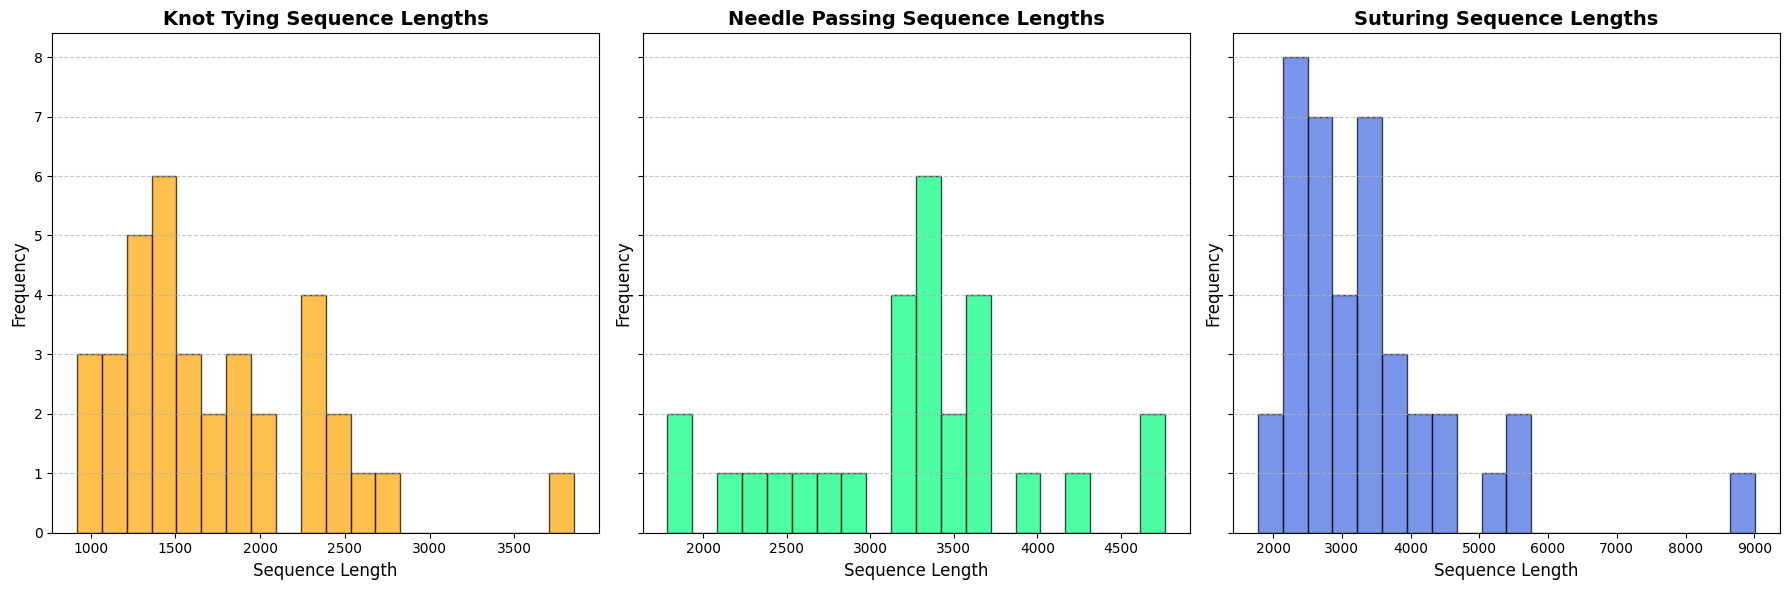

In [ ]:
colors = ["orange", "springgreen", "royalblue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (task, lengths), color in zip(axes, at_data.sequence_lengths.items(), colors):
    ax.hist(lengths, bins=20, color=color, edgecolor="black", alpha=0.7)
    ax.set_title(f"{task} Sequence Lengths", fontsize=14, fontweight="bold")
    ax.set_xlabel("Sequence Length", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### Choosing validation strategy (LOUO / LOSO / LOTO ) and splitting dataset

In [ ]:
def split_data(dataset, strategy):
    """
    Splits the dataset into train and test sets based on the chosen validation strategy.

    Arguments:
    - dataset: Object from JIGSAWSDataset class.
    - strategy: 'LOSO' (Leave-One-Supertrial-Out), 'LOUO' (Leave-One-User-Out), or 'LOTO' (Leave-One-Task-Out).
    Returns:
    - (train_data, test_data): A list of tuples of PyTorch `Subset` objects for each fold/split.
    """
##########################################################
#         Leave-One-Supertrial-Out(LOSO)
##########################################################
    if strategy == 'LOSO':

        all_trials = [trial_id for task in dataset.tasks for trial_id in dataset.trial_ids[task]]

        indices = list(range(len(all_trials)))
        #Create a set with the unique trial_ids--> {1,2,3,4,5}
        unique_trials = set(all_trials)

        #each unique trial
        for trial in unique_trials:

            test_idx = [i for i, t in enumerate(all_trials) if t == trial] #Test set: ONLY the desired trial
            train_idx = [i for i in indices if i not in test_idx]          #Train set: NOT the desired trial
            # Create the necessary subsets
            train_data = Subset(dataset, train_idx)
            test_data = Subset(dataset, test_idx)

            # Output split information (uncomment for debugging)
            #print(f"Trial {trial}:")
            #print(f" Train size = {len(train_data)}")
            #print(f" Test size = {len(test_data)}")

            #Sanity check for test/train data
            #Ensure all test samples belong to the correct trial
            assert all(all_trials[i] == trial for i in test_idx), \
                f"Error: Test set contains incorrect trial data for trial {trial}"
            assert set(train_idx).isdisjoint(set(test_idx)), \
                f"Error: Train and test sets overlap for trial {trial}"

            yield train_data, test_data

##########################################################
#         Leave-One-User-Out(LOUO)
##########################################################
    elif strategy == 'LOUO':

        all_user_ids = [user_id for task in dataset.tasks for user_id in dataset.user_ids[task]]

        indices = list(range(len(all_user_ids)))
        #Create a set with the unique users_ids --> {'B','C','D','E','F','G','H','I'}
        unique_users = set(all_user_ids)

        #each desired user
        for user in unique_users:

            train_idx = [i for i in indices if all_user_ids[i] != user] #Train set: NOT the desired user
            test_idx = [i for i in indices if all_user_ids[i] == user]  #Test set: ONLY the desired user
            #Create the necessary subsets
            train_data = Subset(dataset, train_idx)
            test_data = Subset(dataset, test_idx)

            # Output split information
            #print(f"User {user}:")
            #print(f" Train size = {len(train_data)}")
            #print(f" Test size = {len(test_data)}")

            #Sanity check for test/train data
            #Ensure all the user_ids  in the test data belong ONLY to the the desired_user
            assert set(all_user_ids[i] for i in test_idx) == {user}, \
                f"Error: Test set for user {user} contains data from other users."
            assert set(train_idx).isdisjoint(set(test_idx)), \
                    f"Error: Train and test sets overlap for user {user}"

            yield train_data, test_data

##########################################################
#         Leave-One-Task-Out(LOTO)
##########################################################
    elif strategy == 'LOTO':

        task_indices = {}
        sample_task_labels = []
        start_idx = 0
        #Create a mapping for each task to its corresponding sample indices
        for task in dataset.tasks:
            length = len(dataset.user_ids[task])
            task_indices[task] = list(range(start_idx, start_idx + length))
            sample_task_labels.extend([task] * length)
            start_idx += length

        #each task
        for task, test_idx in task_indices.items():

            train_idx = [i for t, idxs in task_indices.items() if t != task for i in idxs]# Train set: NOT the current task

            train_data = Subset(dataset, train_idx)
            test_data = Subset(dataset, test_idx)

            #Output split information
            #print(f"Task {task}:")
            #print(f"Train size = {len(train_data)}")
            #print(f"Test size = {len(test_data)}")

            #Sanity check for test/train data
            #Ensure that test set contains only the current task
            assert set(sample_task_labels[i] for i in test_idx) == {task}, \
                f"Error: Test set for '{task}' contains data from other tasks."
            assert task not in set(sample_task_labels[i] for i in train_idx), \
                f"Error: Train set contains data from the test task '{task}'"

            yield train_data, test_data
    else:
        raise ValueError("Invalid strategy. Choose from 'LOSO', 'LOUO', or 'LOTO'.")

In [ ]:
def split_train_val(train_data, val_ratio=0.2, seed=42):
    """
    Splits training data into stratified train and validation sets based on skill labels.

    Arguments:
    - train_data: Object from JIGSAWSDataset class dataset, Structure: (data, mosats_label, skill_label).
    - val_ratio: Ration for train/val set, default=0.2
    - seed: Random seed for reproducibility of the split.
    Returns:
    - (train_subset, val_subset): A list of tuples of Subsets of the training_data for train and validation.
    """
    #Train_data format as JIGSAWSDataset object:
    #train_data[0]-->data , train_data[1]-->mosats labels ,train_data[2]-->skill labels
    skill_labels = [np.argmax(sample[2]).item() for sample in train_data]

    #Stratified sampling
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    indices = np.arange(len(train_data)) # 0,1,2....len(train_data)

    for train_idx, val_idx in sss.split(indices, skill_labels):
        return Subset(train_data, train_idx), Subset(train_data, val_idx)

###  Variable sequence length & Windowing

In [ ]:
def collate_fn(batch, target_dtype=torch.float32, use_windows=True, window_size=75, stride=75):
    """
    Handles variable-length kinematic sequences with dynamic padding and generates attention masks for padded sequences.

    Arguments:
    - batch: A list of tuples (sequence, mosat, skill)
    - target_dtype: Dtype for mosats and skill tensors.
    - use_windows: Bool ReCAP-style windowing
    - window_size: Number of timesteps per window, default=75
    - stride: Step size between windows,default=75
    Returns:
    - data_tensor: Tensor of shape
            --> [B, T, F] if use_windows=False
            --> [B, W, window_size, F] if use_windows=True
    - mosats: Tensor [batch_size] for M-OSATS scores
    - skill: Tensor [batch_size] for skill levels
    - task: Tensor [batch_size] for task labels
    - padding_mask: Tensor [batch_size, max_seq_len] only returned if use_windows=False(1 for padding , 0 for real values)
    """

    data, mosats, skill, task = zip(*batch)
    mosats = torch.stack(mosats).to(target_dtype)
    skill = torch.stack(skill).to(target_dtype)

    #Apply windowing if flag=True
    if use_windows:
        all_windowed = []
        window_mask = []
        max_windows = 0
        #Iterate sequences in the batch
        for seq in data:
            seq = seq.numpy()
            windows = [torch.tensor(seq[i:i + window_size], dtype=torch.float32)
                       for i in range(0, len(seq) - window_size + 1, stride)
                      ]
            if not windows:
                windows = [F.pad(torch.tensor(seq, dtype=torch.float32), (0, 0, 0, window_size - len(seq)),mode='constant', value=0)]
            all_windowed.append(torch.stack(windows))  # [num_windows, window_size, features]
            window_mask.append([0] * len(windows))
            max_windows = max(max_windows, len(windows))

        # Paddng number of windows per samlple so each batch have the same number of windows
        padded = []
        for i,w in enumerate(all_windowed):
            pad_len = max_windows - w.shape[0]
            if pad_len > 0:
                pad_windows = torch.zeros((pad_len, window_size, w.shape[2]))
                w = torch.cat([w, pad_windows], dim=0)
                window_mask[i] += [1] * pad_len  # 1 = padding
            padded.append(w)

        data_tensor = torch.stack(padded)  # [B, W, window_size, features]
        window_mask = torch.tensor(window_mask, dtype=torch.bool)  # [B,W]
        padding_mask = None

    else:
        # Dynamic padding based on the longest sequence in the batch
        data_tensor = pad_sequence(data, batch_first=True, padding_value=0.0)
        # Create attention mask: 1 padding, 0 for real in order to pass to TransformerEncoder
        padding_mask = (data_tensor.abs().sum(dim=-1) == 0)  # [B, T]
        window_mask = None

    return data_tensor, mosats, skill, task, padding_mask , window_mask


In [ ]:
def label_smoothing(dataset, smoothing=0.3, num_classes=3):
    """
    Applies label smoothing to the given surgeon's skill labels of train/val/test set.

    Arguments:
    - dataset: Object of the JIGSAWSDataset class
    - smoothing: Ratio of smoothing, default is 0.3
    - num_classes: Number of classes, default is 3 (N, I, E)
    Returns:
    - smooth_dataset: New dataset with smoothed skill labels.
    """
    smoothed_dataset = []
    for data, mosats_label, skill_label,task in dataset:
        #Create a smoothed label vector: (1-smoothing) for the correct class, smoothing/(num_classes-1) for the others
        skill_class_idx = torch.argmax(skill_label)
        smooth_label = torch.full((num_classes,), smoothing / (num_classes - 1))  # Distribute smoothing
        smooth_label[skill_class_idx] = 1.0 - smoothing  # Correct class gets 1 - smoothing
        smoothed_dataset.append((data, mosats_label, smooth_label,task))
    return smoothed_dataset


### Creating train and test loaders

In [ ]:
def get_train_val_test_loaders(dataset, strategy='LOSO', batch_size=4, augmentation_fn=None, smoothing=0.3, scaling_factor=0.02, use_windows=True):
    """
    Splits the dataset into training, validation, and test sets based on the specified strategy
    and returns DataLoaders for each set.

    Arguments:
    - dataset : Object from JIGSAWSDataset class
    - strategy: 'LOSO' (Leave-One-Supertrial-Out), 'LOUO' (Leave-One-User-Out), or 'LOTO' (Leave-One-Task-Out)
    - batch_size : Batch size for each DataLoader , default=8
    - val_ratio : Ratio for train/val set, default=0.2
    - augmentation_fn : Function for data augmentation. If provided, it will be applied ONLY to train set, default=None
    - smoothing: Smoothing factor for label smoothing, default=0.3
    - scaling_factor: Scaling factor for Gaussian noise, default=0.01

    Returns:
    - (train_loader, val_loader, test_loader): A list of tuples of PyTorch DataLoaders for each split.
    """
    splits = split_data(dataset, strategy=strategy)
    loaders = []
    print
    for train_data, test_data in splits:
        #train_subset, val_subset = split_train_val(train_data, val_ratio=val_ratio)

        # Apply data augmentation ONLY to training data
        if augmentation_fn:
            train_data = augmentation_fn(train_data, scaling_factor=scaling_factor)

        # Label smoothing
        train_subset = label_smoothing(train_data, smoothing=smoothing)

        # Create DataLoaders
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_fn, num_workers=0)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate_fn, num_workers=0)

        loaders.append((train_loader,test_loader))

    return loaders


#### Dataloaders info and distribution

In [ ]:
#########################################
#DATALOADERS INFO
#########################################

loaders = get_train_val_test_loaders(at_data, strategy='LOSO', augmentation_fn=None ,batch_size=25)
print(f"Number of splits: {len(loaders)}")

# Iterate over all splits
for i, (train_loader, test_loader) in enumerate(loaders, 1):
    print(f"\n=== Split {i} ===")
    # Train data iteration
    for X, mosats_labels, skill_labels, task, padding_mask, window_mask in train_loader:
        print(f"Train batch - X shape: {X.shape} , M-OSATS shape: {mosats_labels.shape}, "
              f"Skill shape: {skill_labels.shape}, "
              f"Padding mask shape: {padding_mask.shape if padding_mask is not None else 'None'}, "
              f"Window mask shape: {window_mask.shape if window_mask is not None else 'None'}")
    # Test data iteration
    for X, mosats_labels, skill_labels, task, padding_mask, window_mask in test_loader:
      print(f"Test batch - X shape: {X.shape} , M-OSATS shape: {mosats_labels.shape}, "
              f"Skill shape: {skill_labels.shape}, "
              f"Padding mask shape: {padding_mask.shape if padding_mask is not None else 'None'}, "
              f"Window mask shape: {window_mask.shape if window_mask is not None else 'None'}")

    print(f"Total train samples: {len(train_loader.dataset)}")
    print(f"Total test samples: {len(test_loader.dataset)}")

Number of splits: 5

=== Split 1 ===
Train batch - X shape: torch.Size([25, 57, 75, 76]) , M-OSATS shape: torch.Size([25, 6]), Skill shape: torch.Size([25, 3]), Padding mask shape: None, Window mask shape: torch.Size([25, 57])
Train batch - X shape: torch.Size([25, 69, 75, 76]) , M-OSATS shape: torch.Size([25, 6]), Skill shape: torch.Size([25, 3]), Padding mask shape: None, Window mask shape: torch.Size([25, 69])
Train batch - X shape: torch.Size([25, 53, 75, 76]) , M-OSATS shape: torch.Size([25, 6]), Skill shape: torch.Size([25, 3]), Padding mask shape: None, Window mask shape: torch.Size([25, 53])
Train batch - X shape: torch.Size([8, 45, 75, 76]) , M-OSATS shape: torch.Size([8, 6]), Skill shape: torch.Size([8, 3]), Padding mask shape: None, Window mask shape: torch.Size([8, 45])
Test batch - X shape: torch.Size([20, 120, 75, 76]) , M-OSATS shape: torch.Size([20, 6]), Skill shape: torch.Size([20, 3]), Padding mask shape: None, Window mask shape: torch.Size([20, 120])
Total train samp

## *Multi-Task Transformer Model*

#### Architecture

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(23)

Using device: cuda


In [ ]:
#========================================================
# Fusion Block used in the [Quarez et al., 2024]: ReCAP: Recursive Cross Attention Network
#for Pseudo-Label  Generation in Robotic Surgical Skill Assessment
#========================================================
# We take each segment of the sample x_s calculate the self_attention and then we use cross attention between x_s
# and the previous hidden state z_prev(previous windows) : z_s = h(x_s, z_s−1)
# We initialize the z0 as a zero filled tensor
#__________________________________________________________________________________________________________________
class FusionModule(nn.Module):
    def __init__(self, d_model=256, nhead=2, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x_s, z_prev):
        # x_s: (B, 75, D), z_prev: (B, 1, D)
        x1, _ = self.self_attn(x_s, x_s, x_s)           # Self-attention within current window
        x_s = self.norm1(x_s + x1)                      # Add & Norm

        x2, _ = self.cross_attn(x_s, z_prev, z_prev)   # Cross-attention from current window to previous summary
        x_s = self.norm2(x_s + x2)                      # Add & Norm

        x3 = self.ff(x_s)                               # Feedforward
        x_s = self.norm3(x_s + x3)                      # Add & Norm

        z_s = x_s.mean(dim=1, keepdim=True)             # Pool across time steps to get a summary vector (B,1,D)
        return z_s


In [ ]:
# Model tranformer architecture based on  [Vaswani et al., 2023] -- Attention is all you need!
# but here we have one shared encoder and two decoder heads for each task (M-OSATS prediction and Skill level classification).
# Initially, we are checking the performance of the model in one task: M-OSATS prediction.
#_____________________________________________________________________________________

class MultiTaskTransformer(nn.Module):
    def __init__(self, input_dim=76, d_model=128, num_heads=4, shared_layers=1,private_layers=1,
          num_layers=6, d_ff=2048, dropout=0.3,use_cross_attn=True, use_fusion=True, head_type='slp'):
        super(MultiTaskTransformer, self).__init__()

        self.use_cross_attn = use_cross_attn
        self.use_fusion = use_fusion
        self.head_type = head_type

        # Transformer Encoder Layer with attention extraction
        # We use GELU avtivation function as it outperforms classic ReLU
        master_encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
            dim_feedforward=d_ff, dropout=dropout,batch_first=True, activation='gelu' )
        slave_encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
            dim_feedforward=d_ff, dropout=dropout,batch_first=True, activation='gelu')

        self.master_encoder = nn.TransformerEncoder(master_encoder_layer, num_layers=private_layers)
        self.slave_encoder = nn.TransformerEncoder(slave_encoder_layer, num_layers=private_layers)

        #Fusion Block for the recurrent attention
        if self.use_fusion:
            self.fusion_block = FusionModule(d_model=d_model, nhead=num_heads, dropout=dropout)
        # Shared Cross-attention layers
        if self.use_cross_attn:
            self.cross_attn = nn.MultiheadAttention(d_model, num_heads=1, dropout=dropout, batch_first=True)

        # FFNs + LayerNorms after cross-attention (residual path)
        self.master_ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model) )

        self.slave_ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model))

        self.master_norm = nn.LayerNorm(d_model)
        self.slave_norm = nn.LayerNorm(d_model)

        # Input projection layers
        self.master_input_proj = nn.Linear(38, d_model)
        self.slave_input_proj = nn.Linear(38, d_model)

        #Classification heads: 6 OSATS domains × 5 Likert classes = 30 logits
        #self.master_head = nn.Linear(d_model, 6 * 5)
        #self.slave_head = nn.Linear(d_model, 6 * 5)
        if head_type == 'slp':
            self.master_head = nn.Linear(d_model, 6 * 5)
            self.slave_head = nn.Linear(d_model, 6 * 5)
        elif head_type == 'mlp':
            self.master_head = nn.Sequential(nn.Linear(d_model, 128), nn.GELU(), nn.Linear(128, 6 * 5))
            self.slave_head = nn.Sequential(nn.Linear(d_model, 128), nn.GELU(), nn.Linear(128, 6 * 5))
        else:
            raise ValueError(f"Unknown head_type: {head_type}")

        # Store attention weights for visualization (!needed for Attention Visualization part!)
        self.master_attention_weights = []
        self.slave_attention_weights = []

    def forward(self, x, padding_mask=None, window_mask=None):
        #x: (batch_size, num_windows, window_size, input_dim) — windowed input
        B, W, T, _ = x.shape

        master_input = x[:, :,:, :38]  # (batch, seq, :38)
        slave_input = x[:, :,:, 38:]   # (batch, seq, 38:)

        # Clear previous attention weights before each forward pass, for each batch we have new attention weights
        self.master_attention_weights = []
        self.slave_attention_weights = []

        # Initialize hidden states for recursive attention(based on ReCap paper)
        z_master = torch.zeros(B, 1, self.master_input_proj.out_features, device=x.device)
        z_slave  = torch.zeros(B, 1, self.slave_input_proj.out_features, device=x.device)
        master_logits_all = []
        slave_logits_all = []

        #Iterate through windows
        for s in range(W):
          m_win = master_input[:, s]  # (B, T, 38)
          s_win = slave_input[:, s]   # (B, T, 38)

          # Linear projection (residual path) -> (batch_size, seq_len, d_model)
          master_proj = self.master_input_proj(m_win)
          slave_proj = self.slave_input_proj(s_win)

          # Pass through the encoder layer
          master_encoded = self.master_encoder(master_proj)
          slave_encoded = self.slave_encoder(slave_proj)

          # Cross-attention (ablatable)
          if self.use_cross_attn:
                master_attn_output, master_attn = self.cross_attn(
                    master_encoded, slave_encoded, slave_encoded,
                    average_attn_weights=True, need_weights=True)
                slave_attn_output, slave_attn = self.cross_attn(
                    slave_encoded, master_encoded, master_encoded,
                    average_attn_weights=True, need_weights=True)
                self.master_attention_weights.append(master_attn.detach())
                self.slave_attention_weights.append(slave_attn.detach())
          else:
                # Bypass: no cross-stream mixing, each stream only sees its own encoding
                master_attn_output, slave_attn_output = master_encoded, slave_encoded

          # FFN block + residual + norm (PostNorm)
          updated_master = self.master_norm(master_encoded + self.master_ffn(master_attn_output))
          updated_slave = self.slave_norm(slave_encoded + self.slave_ffn(slave_attn_output))


          # Recurrent fusion (ablatable) ---
          if self.use_fusion:
                z_master = self.fusion_block(updated_master, z_master)
                z_slave = self.fusion_block(updated_slave, z_slave)
          else:
              # No recurrent memory across windows - just average within the window
                z_master = updated_master.mean(dim=1, keepdim=True)
                z_slave = updated_slave.mean(dim=1, keepdim=True)

          m_logits = self.master_head(z_master.squeeze(1)).view(B, 6, 5)
          s_logits = self.slave_head(z_slave.squeeze(1)).view(B, 6, 5)

          master_logits_all.append(m_logits)
          slave_logits_all.append(s_logits)

        master_logits_all = torch.stack(master_logits_all, dim=1)  # (B, W, 6, 5)
        slave_logits_all = torch.stack(slave_logits_all, dim=1)

        if window_mask is not None:
            valid = (~window_mask).float().unsqueeze(-1).unsqueeze(-1)  # [B, W, 1, 1]
            sum_valid = valid.sum(dim=1, keepdim=True) + 1e-8
            master_logits_avg = (master_logits_all * valid).sum(dim=1) / sum_valid.squeeze(1)
            slave_logits_avg = (slave_logits_all * valid).sum(dim=1) / sum_valid.squeeze(1)
        else:
            master_logits_avg = master_logits_all.mean(dim=1)
            slave_logits_avg = slave_logits_all.mean(dim=1)

        return slave_logits_avg, master_logits_avg, self.slave_attention_weights, self.master_attention_weights

# Loss functions
mse_loss = nn.MSELoss()    # Mean Squared Error for M-OSATS score regression
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.3) #label smoothing for NP=0.1
grs_loss = torch.nn.SmoothL1Loss(beta=0.5)
mae_loss = torch.nn.L1Loss(reduction='mean')

model = MultiTaskTransformer(
    input_dim=76,
    d_model=256,
    d_ff=1024,
    num_heads= 2,
    num_layers= 2,
    dropout= 0.3
   ).to(device)

# Print model summary (for debugging)
#print(model)

#### Training & Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, median_absolute_error
def accuracy(model, test_loader,task_name=None, filter_task=None, verbose=False,stream_mode='both'):
    model.eval()

    domain_names = ['RT', 'SNH', 'TM', 'FO', 'OP', 'QFP']
    num_domains = len(domain_names)

    # Initialize containers
    domain_trues = [[] for _ in range(num_domains)]
    domain_preds = [[] for _ in range(num_domains)]
    domain_errors = [[] for _ in range(num_domains)]
    grs_trues = []
    grs_preds = []
    per_sample_avg_trues = []
    per_sample_avg_preds = []

    with torch.no_grad():
        for data, mosats, _, task_batch, padding_mask,window_mask in test_loader:
            data, mosats = data.to(device), mosats.to(device)
            padding_mask= padding_mask.to(device) if padding_mask is not None else None
            window_mask= window_mask.to(device) if window_mask is not None else None

            slave_pred, master_pred, _, _ = model(data, padding_mask=padding_mask, window_mask=window_mask)

            # Predicted class indices → Likert scores in [1, 5]
            slave_scores = torch.argmax(slave_pred, dim=-1) + 1  # shape: (batch, 6)
            master_scores = torch.argmax(master_pred, dim=-1) + 1

            if stream_mode == 'master':
                final_pred = master_scores.float()
            elif stream_mode == 'slave':
                final_pred = slave_scores.float()
            else:  # 'both'
                final_pred = (slave_scores + master_scores) / 2

            #final_pred =  (slave_scores + master_scores) / 2
            #final_pred = (0.6 * slave_scores + 0.4 * master_scores)
            #final_pred = torch.min(slave_scores, master_scores)
            final_pred = final_pred.cpu().numpy()#.round(0)
            domain_indices_to_floor = []

            # Apply floor for specific domains, round elsewhere
            for idx in range(final_pred.shape[1]):
                if idx in domain_indices_to_floor:
                    final_pred[:, idx] = np.floor(final_pred[:, idx])
                else:
                    final_pred[:, idx] = np.round(final_pred[:, idx],0)
            if verbose:
            #Debugging
              print(f'Ground truth labels:{mosats} ')
              print(f"Final Prediction for MOSATS:{final_pred}")

            for true, pred, task_label in zip(mosats, final_pred, task_batch):
                task_label = task_label.item() if isinstance(task_label, torch.Tensor) else task_label
                if filter_task and task_label != filter_task:
                    continue
                true = true.cpu().numpy()
                #print(f"Error: {err}")
                #print(f"True GRS: {true_grs}, Predicted GRS: {pred_grs}")
                for i in range(num_domains):
                    domain_trues[i].append(true[i])
                    domain_preds[i].append(pred[i])
                    domain_errors[i].append(abs(true[i] - pred[i]))

                grs_trues.append(true.sum())
                grs_preds.append(pred.sum())
                per_sample_avg_trues.append(np.mean(true))
                per_sample_avg_preds.append(np.mean(pred))


            torch.cuda.empty_cache()

    mae = mean_absolute_error(np.array(grs_preds),np.array(grs_trues))

    # Compute SCC  and MAE between prediction and true MOSATS scores for each domain
    mae_mosats = []
    medae_mosats = []
    scc_mosats = []
    for i in range(num_domains):
        t_true = domain_trues[i]
        t_pred = domain_preds[i]
        abs_err = domain_errors[i]
        mae_i = mean_absolute_error(np.array(t_true),np.array(t_pred))
        medae_i = median_absolute_error(np.array(t_true), np.array(t_pred))
        #print( f"Absolute error {np.abs(np.array(t_true) - np.array(t_pred))}" )
        #if verbose:
          #print(f"MAE (Domain {i}): {mae_i:.3f}")
        mae_mosats.append(mae_i)
        medae_mosats.append(medae_i)
        if np.std(t_true) == 0 or np.std(t_pred) == 0:
            scc = np.nan
        else:
            scc = spearmanr(t_true, t_pred)[0]
        scc_mosats.append(scc)

    # Compute SCC between average predicted and true MOSATS scores
    if np.std(per_sample_avg_trues) == 0 or np.std(per_sample_avg_preds) == 0:
        scc_avrg_mosats = np.nan
    else:
        scc_avrg_mosats = spearmanr(per_sample_avg_trues, per_sample_avg_preds)[0]

    # Compute SCC for GRS
    if np.std(grs_trues) == 0 or np.std(grs_preds) == 0:
        scc_grs = np.nan
    else:
        scc_grs = spearmanr(grs_trues, grs_preds)[0]
    if verbose:
    # Print results
      print("=" * 60)
      print(f"\n=== Task {task_name} ===")
      print(f"MAE (GRS): {mae:.3f}")
      for i, domain in enumerate(domain_names):
          print(f"Spearman (Domain {domain}): {scc_mosats[i]:.3f}")
      print(f"Spearman (GRS): {scc_grs:.3f}")
      print(f"Spearman (Average MOSATS): {scc_avrg_mosats:.3f}")
      print("=" * 60)

    # Return error distributions per domain for further analysis
    error_distributions = {
        domain_names[i]: np.array(domain_errors[i])
        for i in range(num_domains)
    }

    return mae,mae_mosats, scc_mosats,scc_avrg_mosats,scc_grs, medae_mosats, error_distributions


In [ ]:
#######################################
#-------------Training-----------------
######################################
def train(model, train_loader,val_loader,task, strategy='LOSO',
          split_id=None, num_epochs=100, alpha=0.6,beta=0.03, learning_rate=1e-5,
          patience=5, accumulation_steps=2,stream_mode='both'):
    """
    Arguments:
    - model: MultiTaskTransformer model
    - train_loader: DataLoader for the train set
    - strategy: 'LOSO' (Leave-One-Supertrial-Out), 'LOUO' (Leave-One-User-Out), or 'LOTO' (Leave-One-Task-Out) for saving
    - num_epochs: Number of epochs to train the model
    - alpha: Weighting factor for combining MOSATS and skill losses, default 1.0
    - learning_rate: Learning rate for the optimizer, default 1e-4
    - warmup_steps: Number of warm-up steps for learning rate scheduler, default 100
    - patience: Number of epochs with no improvement before early stopping, default 3
    - accumulation_steps: Gradient accumulation steps ,default 4
    """

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = int(0.2 * total_steps)  # 5%
    scheduler = get_cosine_schedule_with_warmup(optimizer,num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    best_loss = float('inf')
    best_mae = float('inf')
    patience_counter = 0

    #List to save the losses for plotting
    train_losses = []
    warmup_epochs = int(0.2 * num_epochs)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True, dynamic_ncols=True)
        optimizer.zero_grad()

        for batch_idx, (data, mosats, skill, task_batch ,padding_mask, window_mask) in enumerate(train_loader_tqdm):
            #Forward pass
            data, mosats, skill = data.to(device), mosats.to(device), skill.to(device)
            padding_mask= padding_mask.to(device) if padding_mask is not None else None
            window_mask= window_mask.to(device) if window_mask is not None else None

            #with autocast():
            slave_pred, master_pred, _, _ = model(data, padding_mask=padding_mask, window_mask=window_mask)

             # mosats: shape (batch, 6), values in [1, 5] → convert to 0–4
            mosats_class = mosats.long() - 1  #shape: (batch, 6, 5) → (batch*6, 5)
            slave_logits = slave_pred.view(-1, 5)
            master_logits = master_pred.view(-1, 5)
            targets = mosats_class.view(-1)  # (batch*6)

            loss_slave = cross_entropy_loss(slave_logits, targets)
            loss_master = cross_entropy_loss(master_logits, targets)
            total_loss = alpha * loss_slave + (1-alpha)*loss_master

            # Backward pass and optimization using gradient accumulation
            total_loss.backward()
            #Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                optimizer.step()
                optimizer.zero_grad()
            scheduler.step()

            running_loss += total_loss.item()
            # Update tqdm description with the current running loss
            current_lr = optimizer.param_groups[0]['lr']
            train_loader_tqdm.set_postfix(train_loss=running_loss/(batch_idx+1), refresh=True,lr=current_lr)
            #del pred_mosats, pred_skill, total_loss
            del slave_pred, master_pred, total_loss

        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # Validation
        val_mae, *_ = accuracy(model, val_loader, task, verbose=False, stream_mode=stream_mode)
        print(f"Epoch [{epoch+1}/{num_epochs}] , Train Loss: {running_loss/len(train_loader):.4f}, Validation MAE GRS: {val_mae:.4f}")

        # Early stopping logic
        if val_mae <= best_mae:
            best_mae = val_mae
            patience_counter = 0
            # Save the best model based on validation loss
            model_path = f'/content/drive/MyDrive/model_{strategy}_{task}_split_{split_id}.pth'
            torch.save(model.state_dict(), model_path)
        else:
            if epoch >= warmup_epochs:
                patience_counter += 1
                if patience_counter >= patience:
                  print(f"Early stopping triggered at epoch {epoch+1}. Best Val MAE: {best_mae:.4f}")
                  break

        torch.cuda.empty_cache()

    # Plotting των training και validation losses
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.show()

    return train_losses

###### LOSO

In [ ]:
#############################
# LEAVE-ONE-SUPERTRIAL-OUT (LOSO) [MODIFIED]
#############################

datasets = {'KT': kt_data,'NP': np_data,'SU': su_data,'AT': at_data}
domain_names = ['RT', 'SNH', 'TM', 'FO', 'OP', 'QFP']
task_names = ['KT', 'NP', 'SU','AT']
#all_tasks = task_names + ['AT']
num_domains = len(domain_names)

# Initialize containers to store results across all splits and tasks
mae_list = {task: [] for task in task_names}
scc_mosats_list = {task: [[] for _ in range(num_domains)] for task in task_names}
mae_mosats_list = {task: [[] for _ in range(num_domains)] for task in task_names}
medae_mosats_list = {task: [[] for _ in range(num_domains)] for task in task_names}
scc_grs_list = {task: [] for task in task_names}
scc_avg_mosats_list = {task: [] for task in task_names}


for task in task_names:
    print(f"===== Running LOSO for task {task} =====")
    dataset = datasets[task]
    # Set custom batch size depending on the task
    batch_size = 25

    loaders = get_train_val_test_loaders(dataset, strategy='LOSO', batch_size=batch_size, augmentation_fn=None, scaling_factor=0.02,)

    for i, (train_loader, test_loader) in enumerate(loaders):
        print(f"--- Split {i+1} ---")

        model = MultiTaskTransformer(
            input_dim=76,
            d_model=256,
            d_ff=1024,
            num_heads=2,
            shared_layers=1,
            private_layers=2,
            dropout=0.3
        ).to(device)

        learning_rate =  5e-4
        if task in ['KT', 'NP', 'SU','AT']:
          model.load_state_dict(torch.load(f'/content/drive/MyDrive/model_LOSO_{task}_split_{i}.pth', weights_only=True), strict=False)
          model.to(device)

        mae, mae_mosats,scc_mosats, scc_avg_mosats, scc_grs, medae_mosats, error_dists = accuracy(model, test_loader, task ,verbose=True)

        # Store metrics ONLY for current task
        mae_list[task].append(mae)
        scc_grs_list[task].append(scc_grs)
        scc_avg_mosats_list[task].append(scc_avg_mosats)
        for d_indx in range(num_domains):
            scc_mosats_list[task][d_indx].append(scc_mosats[d_indx])
            mae_mosats_list[task][d_indx].append(mae_mosats[d_indx])
            medae_mosats_list[task][d_indx].append(medae_mosats[d_indx])

# Calculate means across all splits
mae_mean = {task: np.mean(mae_list[task]) for task in task_names}
mae_std = {task: np.std(mae_list[task]) for task in task_names}
scc_mosats_mean = {task: np.nanmean(scc_mosats_list[task], axis=1) for task in task_names}
scc_mosats_std = {task: np.nanstd(scc_mosats_list[task], axis=1) for task in task_names}
mae_mosats_mean = {task: np.nanmean(mae_mosats_list[task], axis=1) for task in task_names}
mae_mosats_std = {task: np.nanstd(mae_mosats_list[task], axis=1) for task in task_names}
scc_grs_mean = {task: np.nanmean(scc_grs_list[task]) for task in task_names}
scc_grs_std = {task: np.nanstd(scc_grs_list[task]) for task in task_names}
scc_avg_mosats_mean = {task: np.nanmean(scc_avg_mosats_list[task]) for task in task_names}
medae_mosats_mean = {task: np.nanmean(medae_mosats_list[task], axis=1) for task in task_names}
mae_minus_medae = {task: mae_mosats_mean[task] - medae_mosats_mean[task] for task in task_names}


print("\n=== Final Aggregated Results Across All LOSO Splits ===\n")
for task in task_names:
    print(f"--- Task: {task} ---")
    print(f"MAE of GRS: {mae_mean[task]:.3f} ± {mae_std[task]:.3f}")
    for i, domain in enumerate(domain_names):
        print(f"Final SCC across splits (Domain {domain}): {scc_mosats_mean[task][i]:.3f}")
        print(f"Final MAE across splits (Domain {domain}): {mae_mosats_mean[task][i]:.3f} ± {mae_mosats_std[task][i]:.3f} | MedAE: {medae_mosats_mean[task][i]:.3f}")
    print(f"Final SCC across all splits (GRS): {scc_grs_mean[task]:.3f} ± {scc_grs_std[task]:.3f}")
    print(f"Final SCC across all splits (Average MOSATS): {scc_avg_mosats_mean[task]:.3f}\n")


===== Running LOSO for task KT =====
--- Split 1 ---
Ground truth labels:tensor([[2., 2., 2., 2., 2., 3.],
        [4., 3., 3., 3., 3., 4.],
        [3., 1., 2., 3., 2., 3.],
        [4., 2., 2., 3., 3., 4.],
        [3., 2., 2., 3., 3., 3.],
        [2., 2., 1., 1., 1., 2.],
        [2., 1., 1., 1., 1., 3.]], device='cuda:0') 
Final Prediction for MOSATS:[[1. 2. 2. 2. 1. 2.]
 [4. 3. 3. 3. 3. 4.]
 [2. 3. 3. 3. 2. 3.]
 [3. 3. 3. 3. 3. 4.]
 [3. 3. 3. 3. 3. 4.]
 [1. 1. 1. 2. 2. 2.]
 [1. 1. 1. 2. 1. 2.]]

=== Task KT ===
MAE (GRS): 1.429
Spearman (Domain RT): 0.951
Spearman (Domain SNH): 0.300
Spearman (Domain TM): 0.833
Spearman (Domain FO): 0.966
Spearman (Domain OP): 0.840
Spearman (Domain QFP): 0.732
Spearman (GRS): 0.982
Spearman (Average MOSATS): 0.982
--- Split 2 ---
Ground truth labels:tensor([[1., 1., 2., 2., 1., 2.],
        [4., 3., 3., 4., 4., 4.],
        [3., 2., 2., 3., 3., 3.],
        [3., 3., 3., 3., 3., 4.],
        [4., 3., 3., 3., 3., 4.],
        [2., 2., 1., 2., 2., 

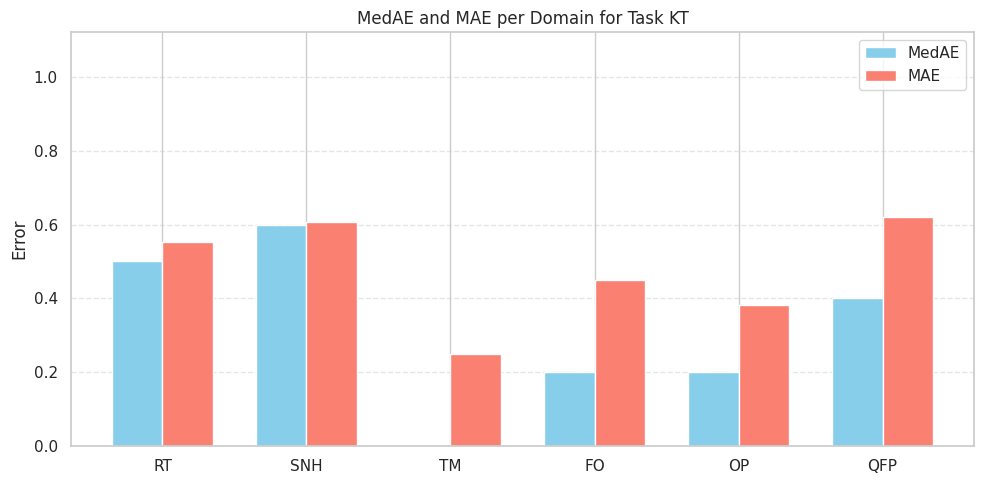

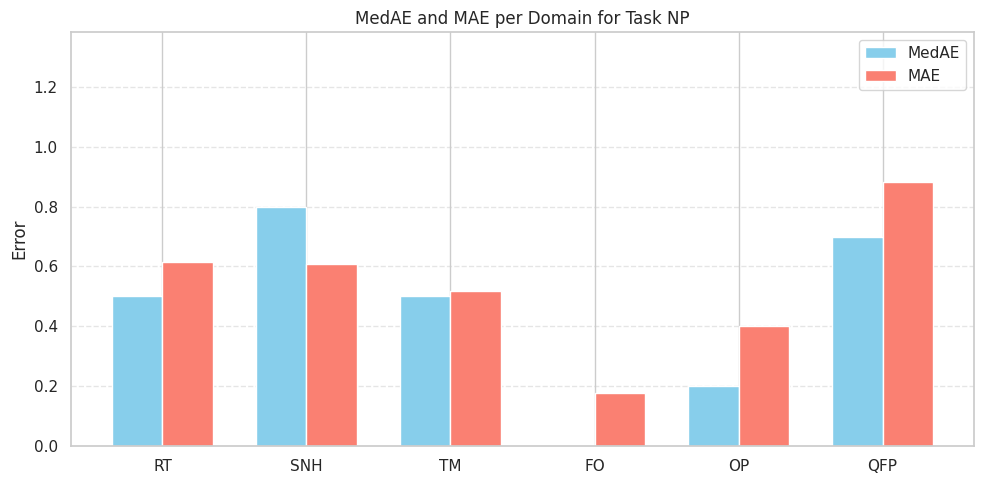

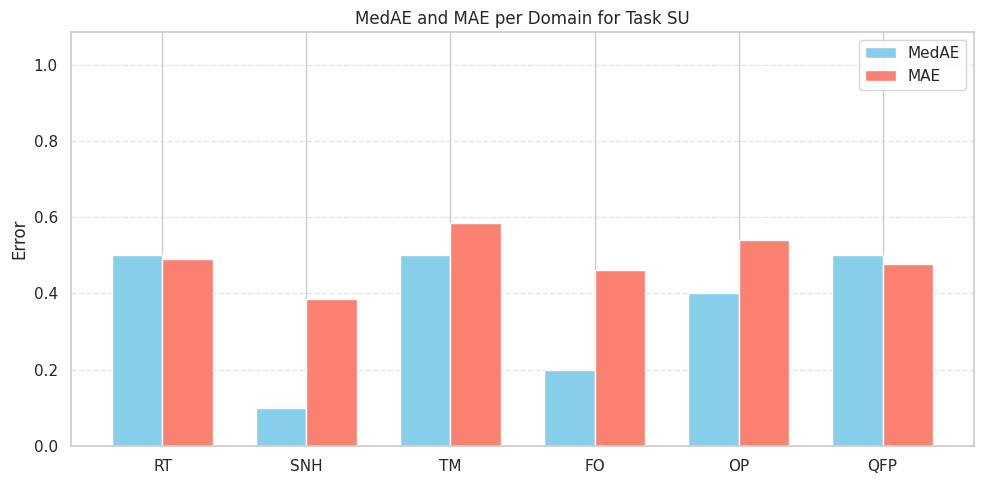

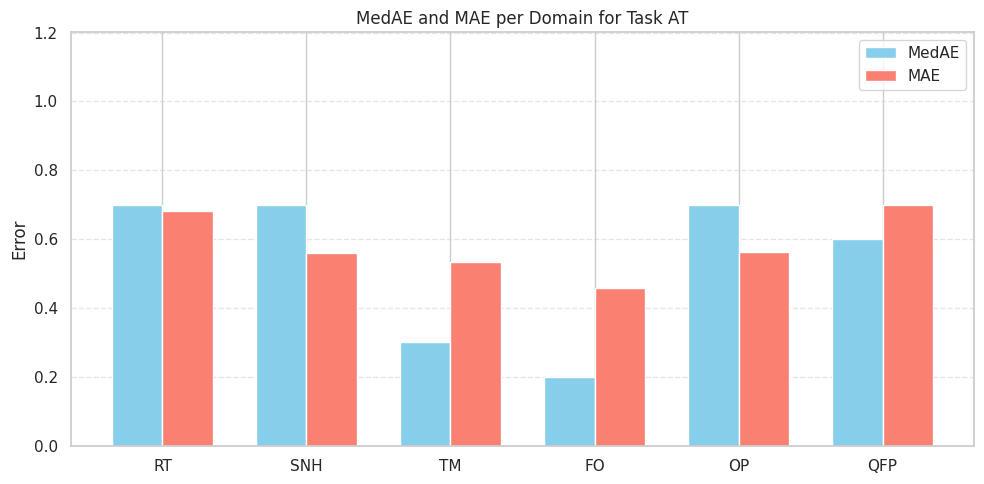

In [ ]:
for task in task_names:
    medae_vals = medae_mosats_mean[task]
    mae_vals = mae_mosats_mean[task]

    x = np.arange(len(domain_names))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, medae_vals, width, label='MedAE', color='skyblue')
    plt.bar(x + width/2, mae_vals, width, label='MAE', color='salmon')

    plt.xticks(x, domain_names)
    plt.title(f"MedAE and MAE per Domain for Task {task}")
    plt.ylabel("Error")
    plt.ylim(0, max(max(medae_vals), max(mae_vals)) + 0.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
print("\n=== Evaluating AT Model Separately on Each Task in the Test Set ===\n")

tasks_to_eval = ['KT', 'NP', 'SU']
at_metrics = {t: {'mae': [], 'mae_mosats': [[] for _ in range(num_domains)],
                  'medae_mosats': [[] for _ in range(num_domains)],
                  'scc_mosats': [[] for _ in range(num_domains)],
                  'scc_avg': [], 'scc_grs': [], 'error_dists': {d: [] for d in domain_names}
                  } for t in tasks_to_eval}

# Evaluate each AT model split
loaders = get_train_val_test_loaders(at_data, strategy='LOSO', batch_size=25, augmentation_fn=None, scaling_factor=0.02)

for i, (train_loader, test_loader) in enumerate(loaders):
    print(f"=== Fold {i} | Loading model_LOSO_AT_split_{i}.pth ===")
    model = MultiTaskTransformer(input_dim=76, d_model=256, d_ff=1024, num_heads=2,
                                 shared_layers=1, private_layers=2, dropout=0.3).to(device)
    model.load_state_dict(torch.load(f'/content/drive/MyDrive/model_LOSO_AT_split_{i}.pth', weights_only=True), strict=False)
    model.to(device)

    for task in tasks_to_eval:
        mae, mae_mosats, scc_mosats, scc_avg, scc_grs, medae_mosats , error_dists= accuracy(model, test_loader, task_name=i, filter_task=task, verbose=False)

        at_metrics[task]['mae'].append(mae)
        at_metrics[task]['scc_avg'].append(scc_avg)
        at_metrics[task]['scc_grs'].append(scc_grs)
        for d in range(num_domains):
            at_metrics[task]['mae_mosats'][d].append(mae_mosats[d])
            at_metrics[task]['medae_mosats'][d].append(medae_mosats[d])
            at_metrics[task]['scc_mosats'][d].append(scc_mosats[d])

# Average metrics across folds
for task in tasks_to_eval:
    print(f"\n=== Task {task} | Evaluated with AT model ===")
    print(f"MAE (GRS): {np.nanmean(at_metrics[task]['mae']):.3f}")
    print(f"SCC (GRS): {np.nanmean(at_metrics[task]['scc_grs']):.3f}")
    print(f"SCC (Avg MOSATS): {np.nanmean(at_metrics[task]['scc_avg']):.3f}")
    for d, domain in enumerate(domain_names):
        mae_avg = np.nanmean(at_metrics[task]['mae_mosats'][d])
        medae_avg = np.nanmean(at_metrics[task]['medae_mosats'][d])
        scc_avg = np.nanmean(at_metrics[task]['scc_mosats'][d])
        print(f"Domain {domain} → MAE: {mae_avg:.3f} | MedAE: {medae_avg:.3f} | SCC: {scc_avg:.3f}")


=== Evaluating AT Model Separately on Each Task in the Test Set ===

=== Fold 0 | Loading model_LOSO_AT_split_0.pth ===
=== Fold 1 | Loading model_LOSO_AT_split_1.pth ===
=== Fold 2 | Loading model_LOSO_AT_split_2.pth ===
=== Fold 3 | Loading model_LOSO_AT_split_3.pth ===
=== Fold 4 | Loading model_LOSO_AT_split_4.pth ===

=== Task KT | Evaluated with AT model ===
MAE (GRS): 2.264
SCC (GRS): 0.813
SCC (Avg MOSATS): 0.813
Domain RT → MAE: 0.864 | MedAE: 1.000 | SCC: 0.607
Domain SNH → MAE: 0.554 | MedAE: 0.700 | SCC: 0.636
Domain TM → MAE: 0.389 | MedAE: 0.000 | SCC: 0.714
Domain FO → MAE: 0.425 | MedAE: 0.400 | SCC: 0.850
Domain OP → MAE: 0.443 | MedAE: 0.300 | SCC: 0.722
Domain QFP → MAE: 0.604 | MedAE: 0.400 | SCC: 0.608

=== Task NP | Evaluated with AT model ===
MAE (GRS): 3.237
SCC (GRS): 0.727
SCC (Avg MOSATS): 0.727
Domain RT → MAE: 0.711 | MedAE: 0.800 | SCC: 0.506
Domain SNH → MAE: 0.608 | MedAE: 0.600 | SCC: 0.624
Domain TM → MAE: 0.563 | MedAE: 0.300 | SCC: 0.577
Domain FO →

In [ ]:
#Efficiency Metrics : Params, FLOPs, Model Size, Inference Latency per window and per trial
model.load_state_dict(torch.load('/content/drive/MyDrive/model_LOSO_AT_split_0.pth', weights_only=True), strict=False)
model.eval()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,} ({n_params/1e6:.2f} M)")
model_size_mb = n_params * 4 / (1024 ** 2)
print(f"Model size (fp32): {model_size_mb:.2f} MB")

def make_dummy_input(batch_size=1, num_windows=1, window_size=75, input_dim=76):
    x = torch.randn(batch_size, num_windows, window_size, input_dim, device=device)
    return x

#FLOPs for a SINGLE window (W=1)
dummy_single_window = make_dummy_input(batch_size=1, num_windows=1)
with sdpa_kernel(SDPBackend.MATH):
    flops_single = FlopCountAnalysis(model, dummy_single_window)
    flops_single.unsupported_ops_warnings(False)  # remaining unsupported ops are cheap elementwise (mul/add/gelu/mean)
    gflops_per_window = flops_single.total() / 1e9
print(f"FLOPs per window (W=1, math SDPA backend): {gflops_per_window:.4f} GFLOPs")

#Per-window inference latency (batch size 1, with warmup)
n_warmup = 20
n_runs = 500
with torch.no_grad():
    for _ in range(n_warmup):
        _ = model(dummy_single_window)
    if device.type == "cuda":
        torch.cuda.synchronize()

    timings = []
    for _ in range(n_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(dummy_single_window)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        timings.append((t1 - t0) * 1000.0)  # ms

per_window_latency_ms = np.mean(timings)
per_window_latency_std = np.std(timings)
print(f"Per-window latency: {per_window_latency_ms:.3f} +/- {per_window_latency_std:.3f} ms "
      f"(mean +/- std over {n_runs} runs, {device.type})")

# Per-trial latency: uses the actual trial lengths from the dataset (same source as histogram figure)
# at_data.sequence_lengths is a dict {task_name: [list of trial lengths]}
window_size = 75
task_name_map = {"Knot Tying": "KT", "Needle Passing": "NP", "Suturing": "SU"}

print("\nPer-task window counts, estimated vs. measured per-trial latency:")
print(f"{'Task':<6}{'N trials':<10}{'Mean len':<12}{'Mean W':<10}"
      f"{'Est. latency':<15}{'Measured latency':<20}")

per_task_stats = {}
n_trial_warmup = 10
n_trial_runs = 50

for task_full, lengths in at_data.sequence_lengths.items():
    lengths = np.array(lengths)
    n_windows = np.floor(lengths / window_size).astype(int)
    n_windows = np.clip(n_windows, 1, None)  # avoid W=0 edge case

    mean_len, median_len = lengths.mean(), np.median(lengths)
    mean_w, median_w = n_windows.mean(), np.median(n_windows)
    est_latency_mean_w = per_window_latency_ms * mean_w

    #Real forward pass with W = round(mean_w) windows
    W_real = int(round(mean_w))
    dummy_trial = make_dummy_input(batch_size=1, num_windows=W_real)
    with torch.no_grad():
        for _ in range(n_trial_warmup):
            _ = model(dummy_trial)
        if device.type == "cuda":
            torch.cuda.synchronize()

        trial_timings = []
        for _ in range(n_trial_runs):
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(dummy_trial)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            trial_timings.append((t1 - t0) * 1000.0)

    measured_latency_ms = np.mean(trial_timings)
    measured_latency_std = np.std(trial_timings)

    short_name = task_name_map.get(task_full, task_full)
    per_task_stats[short_name] = {
        "n_trials": len(lengths),
        "mean_len": mean_len, "median_len": median_len,
        "mean_w": mean_w, "median_w": median_w,
        "est_latency_ms": est_latency_mean_w,
        "measured_latency_ms": measured_latency_ms,
        "measured_latency_std": measured_latency_std,
    }
    print(f"{short_name:<6}{len(lengths):<10}{mean_len:<12.1f}{mean_w:<10.2f}"
          f"{est_latency_mean_w:<15.2f}"
          f"{measured_latency_ms:.2f} +/- {measured_latency_std:.2f} ms")


Trainable parameters: 5,169,212 (5.17 M)
Model size (fp32): 19.72 MB


cross_attn.out_proj, fusion_block.cross_attn.out_proj, fusion_block.self_attn.out_proj, master_encoder.layers.0.self_attn.out_proj, master_encoder.layers.1.self_attn.out_proj, slave_encoder.layers.0.self_attn.out_proj, slave_encoder.layers.1.self_attn.out_proj


FLOPs per window (W=1, math SDPA backend): 0.4474 GFLOPs
Per-window latency: 4.681 +/- 0.155 ms (mean +/- std over 500 runs, cuda)

Per-task window counts, estimated vs. measured per-trial latency:
Task  N trials  Mean len    Mean W    Est. latency   Measured latency    
KT    36        1724.6      22.56     105.58         100.49 +/- 0.91 ms
NP    28        3244.6      42.82     200.44         190.43 +/- 3.52 ms
SU    39        3368.7      44.44     208.00         192.90 +/- 1.07 ms


In [ ]:
from tabulate import tabulate

domains = ['RT', 'SNH', 'TM', 'FO', 'OP', 'QFP']
metrics = ['GRS', 'MAE']
tasks = ['KT', 'NP', 'SU', 'AT']
sep_task = ['KT', 'NP', 'SU']
headers1 = ["Method", "KT", "NP", "SU", "AT"]
headers2 = ["Metric/Domain"] + tasks
headers3 = ["Input", "Method", "KT", "NP", "SU", "AT"]
headers4 = ["Metric/Domain", "KT","NP","SU"]
headers5 = ["Metric"] + sep_task


# ReCAP values
recap_mosats = {
    'KT': [0.78, 0.61, 0.80, 0.63, 0.79, 0.59],
    'NP': [0.43, 0.69, 0.72, 0.45, 0.23, 0.22],
    'SU': [0.52, 0.78, 0.60, 0.66, 0.50, 0.64],
    'AT': [0.56, 0.65, 0.62, 0.64, 0.65, 0.62]
}

#Table 1: MOSATS Average Domain Scores
table1 = [
    ["Apen", 0.66, 0.45, 0.59, 0.57],
    ["FCN", 0.65, 0.57, 0.60, 0.61],
    ["ReCAP", 0.70, 0.46, 0.62, "0.59/0.58*"],
    ["MTT(Proposed)"] + [
        f"{scc_avg_mosats_mean[task]:.2f}" for task in ['KT', 'NP', 'SU']
    ] + [
        f"{np.mean([scc_avg_mosats_mean[t] for t in ['KT', 'NP', 'SU']]):.2f}/"
        f"{scc_avg_mosats_mean['AT']:.2f}*"
    ]
]
# Table 2: SCC MOSATS Domain Scores
table2 = [
    [domain] + [
        f"{scc_mosats_mean[task][i]:.3f} / {recap_mosats[task][i]:.2f}"
        for task in tasks]  for i, domain in enumerate(domains) ]
avg_mine = [np.mean(scc_mosats_mean[task]) for task in tasks]
avg_recap = [np.mean(recap_mosats[task] ) for task in tasks]
avg_row = ['AVG'] + [f"{m:.3f}/ {r:.2f}" for m, r in zip(avg_mine, avg_recap)] + [f"{np.mean(avg_mine):.3f} / {np.mean(avg_recap):.2f}" ]
table2.append(avg_row)

# Table 3: MAE per MOSATS Domain (Ours Only)
table3 = [
    [domain] + [f"{mae_mosats_mean[task][i]:.3f} ({mae_mosats_std[task][i]:.3f})" for task in tasks]
    for i, domain in enumerate(domains)
]
avg_mae_mosats = [np.mean(mae_mosats_mean[task]) for task in tasks]
table3.append(["AVG"] + [f"{v:.3f}" for v in avg_mae_mosats])

# Table 4: GRS Score Performance ===
table4 = []
# SCC rows
table4.append(["", "**Spearman Correlation Co. (SCC)**", ""])
table4 += [
    ["V", "C3D-MTL-VF", 0.89, 0.75, 0.77, 0.81],
    ["V", "Contra-Sformer", "0.89(0.067)", "0.71(0.104)", "0.86(0.056)", "0.83(0.079)"],
    ["V", "ViSA", 0.92, 0.93, 0.84, 0.90],
    ["K", "SMT-DCT-DFT", 0.70, 0.38, 0.64, 0.59],
    ["K", "DCT-DFT-ApEn", 0.63, 0.46, 0.75, 0.63],
    ["K", "ReCAP", 0.88, 0.85, 0.83, "0.86/0.79*"],
    ["K", "MTT (Proposed)",
     f"{scc_grs_mean['KT']:.2f} ({scc_grs_std['KT']:.2f})",
     f"{scc_grs_mean['NP']:.2f} ({scc_grs_std['NP']:.2f})",
     f"{scc_grs_mean['SU']:.2f} ({scc_grs_std['SU']:.2f})",
     f"{np.mean([scc_grs_mean[t] for t in ['KT', 'NP', 'SU']]):.2f} /{scc_grs_mean['AT']:.2f}* ( {scc_grs_std['AT']:.2f})"
    ]
]
# Add MAE label row
table4.append(["", "**Mean Absolute Error (MAE)**", "", "", "", ""])
# MAE rows
table4 += [
    ["V", "Contra-Sformer", "1.75(0.68)", "3.15(0.89)", "2.74(0.87)", 2.55],
    ["V", "ViSA", 2.16, 1.66, 2.58, 2.13],
    ["K", "ReCAP", 2.04, 3.12, 2.89, "2.68/2.71*"],
    ["K", "MTT (Proposed)",
     f"{mae_mean['KT']:.2f} ({mae_std['KT']:.2f})",
     f"{mae_mean['NP']:.2f} ({mae_std['NP']:.2f})",
     f"{mae_mean['SU']:.2f} ({mae_std['SU']:.2f})",
     f"{np.mean([mae_mean[t] for t in ['KT', 'NP', 'SU']]):.2f} /{mae_mean['AT']:.2f} ({mae_std['AT']:.2f})*"
    ]
]


# Table 5: AT-Trained Model - SCC per MOSATS Domain (Tested Per Task)
table5 = [
    [domain] + [f"{np.mean(at_metrics[task]['scc_mosats'][i]):.3f}" for task in sep_task]
    for i, domain in enumerate(domains)
]
avg_at_scc = [np.mean([np.mean(at_metrics[task]['scc_mosats'][i]) for i in range(len(domains))]) for task in sep_task]
table5.append(["AVG"] + [f"{v:.3f}" for v in avg_at_scc])

# Table 6: AT-Trained Model - MAE per MOSATS Domain (Tested Per Task)
table6 = [
    [domain] + [f"{np.mean(at_metrics[task]['mae_mosats'][i]):.3f} ({np.std(at_metrics[task]['mae_mosats'][i]):.3f})"
        for task in sep_task] for i, domain in enumerate(domains)]

# Compute average MAE per task (averaging across all domains)
avg_at_mae = [ np.mean([np.mean(at_metrics[task]['mae_mosats'][i]) for i in range(len(domains))])for task in sep_task ]
avg_at_std = [np.std([np.mean(at_metrics[task]['mae_mosats'][i]) for i in range(len(domains))])for task in sep_task]
# Add row with mean ± std across domains
table6.append(["AVG"] + [f"{m:.3f} ({s:.3f})" for m, s in zip(avg_at_mae, avg_at_std)])

# Table 7: AT-Trained Model - MAE and SCC for GRS
table7 = [
    ['SCC GRS'] + [f"{np.mean(at_metrics[task]['scc_grs']):.3f} ({np.std(at_metrics[task]['scc_grs']):.3f})" for task in sep_task],
    ['MAE GRS'] + [f"{np.mean(at_metrics[task]['mae']):.3f} ({np.std(at_metrics[task]['mae']):.3f})" for task in sep_task] ]


print("="*60)
print(" " * 20 + "LOSO strategy")
print("="*60)
print("\n--- TABLE I: Averaged MOSATS Scores Performance ---")
print("Where the ρMOSATS is the average SCC across the 6 MOSATS domains under LOSO scheme.")
print("*: Results from training across the three tasks. ACROSS TASKS (AT).")
print(tabulate(table1, headers=headers1, tablefmt="github"))
print()
print("---TABLE II: MOSATS Domain Performance---")
print(" Where ρMOSATS is reported for RT: Respect for tissue, TM: Time and Motion, OP: Overall Performance,")
print("SNH: Suture and Needle Handling, FO: Flow of Operation, QFP: Quality of Final Product under LOSO scheme.")
print("Across tasks (AT) is trained on the three tasks.")
print(f"{'MTT (Ours) vs ReCAP':^90}")
print(tabulate(table2, headers=headers2, tablefmt="github"))
print()
print("\n--- TABLE III: AT-Trained Model – Spearman Correlation Coefficient (SCC) per MOSATS Domain ---")
print("This table reports the Spearman Correlation Coefficient (SCC) values for each MOSATS domain, ")
print("evaluated by applying a single model trained on all tasks jointly (Across Tasks - AT) ")
print("to each individual surgical task separately (Knot Tying (KT), Needle Passing (NP), Suturing (SU)). ")
print("Higher SCC indicates better agreement between predicted and true MOSATS scores, reflecting the model's ability to capture ")
print("domain-specific surgical skill nuances across tasks.")
print(tabulate(table5, headers=headers4, tablefmt="github"))
print()
print("--- TABLE IV: MAE per MOSATS Domain ---")
print("Mean Absolute Error is reported for RT: Respect for tissue, TM: Time and Motion, OP: Overall Performance,")
print("SNH: Suture and Needle Handling, FO: Flow of Operation, QFP: Quality of Final Product under LOSO scheme.")
print("Across tasks (AT) is trained on the three tasks. ( ): Standard deviation")
print(tabulate(table3, headers=headers2, tablefmt="github"))
print("\n--- TABLE V: AT-Trained Model – Mean Absolute Error (MAE) per MOSATS Domain ---")
print("This table shows the Mean Absolute Error (MAE) for each MOSATS domain, obtained by testing the Across Tasks (AT) trained model ")
print("individually on each surgical task (KT, NP, SU) as well as on the combined dataset (AT). ")
print("Lower MAE values indicate more accurate predictions of MOSATS domain scores, representing the model’s precision in evaluating ")
print("various aspects of surgical performance across different tasks.")
print(tabulate(table6, headers=headers4, tablefmt="github"))
print()
print("\n--- Table VI: GRS Score Perfomance Comparison ---")
print("K: Kinematic data, V: Video data.*: Results from training across the three tasks. ACROSS TASKS (AT).")
print("( ): Standard deviation. Reported for SCC and MAE.")
print(tabulate(table4, headers=headers3, tablefmt="github"))
print("\n--- TABLE VII: GRS SCC and MAE (AT-Trained Model Tested Per Task) ---")
print("Mean across folds for each test task.")
print(tabulate(table7, headers=headers5, tablefmt="github"))
print()



                    LOSO strategy

--- TABLE I: Averaged MOSATS Scores Performance ---
Where the ρMOSATS is the average SCC across the 6 MOSATS domains under LOSO scheme.
*: Results from training across the three tasks. ACROSS TASKS (AT).
| Method        |   KT |   NP |   SU | AT         |
|---------------|------|------|------|------------|
| Apen          | 0.66 | 0.45 | 0.59 | 0.57       |
| FCN           | 0.65 | 0.57 | 0.6  | 0.61       |
| ReCAP         | 0.7  | 0.46 | 0.62 | 0.59/0.58* |
| MTT(Proposed) | 0.87 | 0.84 | 0.81 | 0.84/0.77* |

---TABLE II: MOSATS Domain Performance---
 Where ρMOSATS is reported for RT: Respect for tissue, TM: Time and Motion, OP: Overall Performance,
SNH: Suture and Needle Handling, FO: Flow of Operation, QFP: Quality of Final Product under LOSO scheme.
Across tasks (AT) is trained on the three tasks.
                                   MTT (Ours) vs ReCAP                                    
| Metric/Domain   | KT           | NP           | SU        

In [ ]:
sep_task = ['KT', 'NP', 'SU']
domains = ['RT', 'SNH', 'TM', 'FO', 'OP', 'QFP']

#Paper Table III: Domain-wise SCC and MAE, ST-LOSO (left) vs CT-LOSO (right)
table_paperIII_scc = [
    [domain] + [
        f"{scc_mosats_mean[task][i]:.3f}({scc_mosats_std[task][i]:.3f}) / "
        f"{np.nanmean(at_metrics[task]['scc_mosats'][i]):.3f}"
        f"({np.nanstd(at_metrics[task]['scc_mosats'][i]):.3f})"
        for task in sep_task
    ]
    for i, domain in enumerate(domains)
]
avg_scc_st = [np.nanmean(scc_mosats_mean[task]) for task in sep_task]
avg_scc_ct = [np.nanmean([np.nanmean(at_metrics[task]['scc_mosats'][d]) for d in range(len(domains))])
              for task in sep_task]
table_paperIII_scc.append(
    ["AVG"] + [f"{s:.3f} / {c:.3f}" for s, c in zip(avg_scc_st, avg_scc_ct)]
)

table_paperIII_mae = [
    [domain] + [
        f"{mae_mosats_mean[task][i]:.3f}({mae_mosats_std[task][i]:.3f}) / "
        f"{np.nanmean(at_metrics[task]['mae_mosats'][i]):.3f}"
        f"({np.nanstd(at_metrics[task]['mae_mosats'][i]):.3f})"
        for task in sep_task
    ]
    for i, domain in enumerate(domains)
]
avg_mae_st = [np.nanmean(mae_mosats_mean[task]) for task in sep_task]
avg_mae_ct = [np.nanmean([np.nanmean(at_metrics[task]['mae_mosats'][d]) for d in range(len(domains))])
              for task in sep_task]
table_paperIII_mae.append(
    ["AVG"] + [f"{s:.3f} / {c:.3f}" for s, c in zip(avg_mae_st, avg_mae_ct)]
)

print("\n--- PAPER TABLE III: Domain-wise SCC (ST-LOSO / CT-LOSO), mean(std) ---")
print(tabulate(table_paperIII_scc, headers=["Domain"] + sep_task, tablefmt="github"))

print("\n--- PAPER TABLE III: Domain-wise MAE (ST-LOSO / CT-LOSO), mean(std) ---")
print(tabulate(table_paperIII_mae, headers=["Domain"] + sep_task, tablefmt="github"))


#Paper Table IV: GRS SCC and MAE, ST-LOSO (left) vs CT-LOSO (right)

table_paperIV = [
    ["SCC"] + [
        f"{scc_grs_mean[task]:.3f}({scc_grs_std[task]:.3f}) / "
        f"{np.nanmean(at_metrics[task]['scc_grs']):.3f}"
        f"({np.nanstd(at_metrics[task]['scc_grs']):.3f})"
        for task in sep_task
    ],
    ["MAE"] + [
        f"{mae_mean[task]:.3f}({mae_std[task]:.3f}) / "
        f"{np.nanmean(at_metrics[task]['mae']):.3f}"
        f"({np.nanstd(at_metrics[task]['mae']):.3f})"
        for task in sep_task
    ],
]

print("\n--- PAPER TABLE IV: GRS SCC and MAE (ST-LOSO / CT-LOSO), mean(std) ---")
print(tabulate(table_paperIV, headers=["Metric"] + sep_task, tablefmt="github"))

###### LOUO

In [ ]:
#############################
# LEAVE-ONE-USER-OUT (LOUO)
#############################

import os

datasets = {'KT': kt_data, 'NP': np_data, 'SU': su_data}
task_names = ['KT', 'NP', 'SU']

mae_list = {task: [] for task in task_names}
scc_grs_list = {task: [] for task in task_names}

with open('/content/drive/MyDrive/best_params_LOUO.pkl', "rb") as f:
    best_params = pickle.load(f)
print(best_params)

for task in task_names:
    print(f"===== Running LOUO for task {task} =====")
    dataset = datasets[task]
    batch_size=25

    loaders = get_train_val_test_loaders(dataset, strategy='LOUO', batch_size=batch_size, augmentation_fn=None, scaling_factor=0.02,)

    for i, (train_loader, test_loader) in enumerate(loaders):
        print(f"--- Split {i+1} ---")
        ckpt_path = f'/content/drive/MyDrive/model_LOUO_{task}_split_{i}.pth'

        model = MultiTaskTransformer(
            input_dim=76,
            d_model=256,
            d_ff=1024,
            num_heads=2,
            private_layers=2,
            dropout=0.3
          ).to(device)

        learning_rate =  5e-4

        if os.path.exists(ckpt_path):
            print(f"    Split {i}: found existing checkpoint, loading instead of retraining")
            model.load_state_dict(torch.load(ckpt_path, weights_only=True), strict=False)
        else:
            train(model, train_loader, val_loader=test_loader, task=task, strategy='LOUO',
                split_id=i, alpha=0.6, num_epochs=150, accumulation_steps=1, patience=15 , learning_rate=learning_rate, stream_mode='both')
            model.load_state_dict(torch.load(ckpt_path, weights_only=True), strict=False)

        mae, mae_mosats, scc_mosats, scc_avg_mosats, scc_grs, medae_mosats, error_dists = \
            accuracy(model, test_loader, task, verbose=True)

        mae_list[task].append(mae)
        scc_grs_list[task].append(scc_grs)

mae_mean = {task: np.mean(mae_list[task]) for task in task_names}
mae_std = {task: np.std(mae_list[task]) for task in task_names}
scc_grs_mean = {task: np.nanmean(scc_grs_list[task]) for task in task_names}
scc_grs_std = {task: np.nanstd(scc_grs_list[task]) for task in task_names}

print("\n=== Final Aggregated GRS Results Across All LOUO Splits ===\n")
for task in task_names:
    print(f"--- Task: {task} ---")
    print(f"SCC (GRS): {scc_grs_mean[task]:.3f} ± {scc_grs_std[task]:.3f}")
    print(f"MAE (GRS): {mae_mean[task]:.3f} ± {mae_std[task]:.3f}\n")

In [ ]:
from tabulate import tabulate

tasks = ['KT', 'NP', 'SU']
table_grs = [
    ["SCC"] + [f"{scc_grs_mean[task]:.3f}({scc_grs_std[task]:.3f})" for task in tasks],
    ["MAE"] + [f"{mae_mean[task]:.3f}({mae_std[task]:.3f})" for task in tasks],
]

print("=" * 60)
print(" " * 18 + "LOUO strategy — GRS only")
print("=" * 60)
print(tabulate(table_grs, headers=["Metric"] + tasks, tablefmt="github"))

                  LOUO strategy — GRS only
| Metric   | KT           | NP           | SU           |
|----------|--------------|--------------|--------------|
| SCC      | 0.127(0.392) | 0.391(0.575) | 0.421(0.287) |
| MAE      | 1.858(0.731) | 2.288(1.083) | 3.312(1.708) |


#### Ablation Study

In [ ]:
import pickle, os

ABLATION_DIR = '/content/drive/MyDrive/ablation_results'
os.makedirs(ABLATION_DIR, exist_ok=True)

ablation_variants = {
    'baseline':      dict(use_cross_attn=True,  use_fusion=True,  head_type='slp', alpha=0.6, stream_mode='both'),
    'no_cross_attn': dict(use_cross_attn=False, use_fusion=True,  head_type='slp', alpha=0.6, stream_mode='both'),
    'no_fusion':     dict(use_cross_attn=True,  use_fusion=False, head_type='slp', alpha=0.6, stream_mode='both'),
    'mlp_heads':     dict(use_cross_attn=True,  use_fusion=True,  head_type='mlp', alpha=0.6, stream_mode='both'),
    'master_only':   dict(use_cross_attn=True,  use_fusion=True,  head_type='slp', alpha=0.0, stream_mode='master'),
    'slave_only':    dict(use_cross_attn=True,  use_fusion=True,  head_type='slp', alpha=1.0, stream_mode='slave'),
}

ablation_tasks = ['KT', 'NP', 'SU', 'AT']
datasets = {'KT': kt_data, 'NP': np_data, 'SU': su_data, 'AT': at_data}

completed_variants = set()
for fname in os.listdir(ABLATION_DIR):
    if fname.startswith('results_') and fname.endswith('.pkl'):
        completed_variants.add(fname[len('results_'):-len('.pkl')])

ablation_results = {}
for vname in completed_variants:
    with open(f'{ABLATION_DIR}/results_{vname}.pkl', 'rb') as f:
        ablation_results[vname] = pickle.load(f)
    print(f"Loaded previously completed variant: {vname}")

for vname, vcfg in ablation_variants.items():
    if vname in completed_variants:
        print(f"===== Skipping {vname} (already completed) =====")
        continue

    print(f"===== Variant: {vname} =====")
    arch_kwargs = dict(use_cross_attn=vcfg['use_cross_attn'],
                        use_fusion=vcfg['use_fusion'],
                        head_type=vcfg['head_type'])
    alpha = vcfg['alpha']
    stream_mode = vcfg['stream_mode']
    strategy_tag = f'ABL_{vname}'   # this becomes part of the saved checkpoint filename via train()

    variant_results = {task: {'mae_grs': [], 'scc_grs': []} for task in ablation_tasks}

    for task in ablation_tasks:
        print(f"--- Task {task} ---")
        dataset = datasets[task]
        loaders = get_train_val_test_loaders(dataset, strategy='LOSO', batch_size=25,
                                              augmentation_fn=None, scaling_factor=0.02)

        for i, (train_loader, test_loader) in enumerate(loaders):
            ckpt_path = f'/content/drive/MyDrive/model_{strategy_tag}_{task}_split_{i}.pth'

            model = MultiTaskTransformer(
                input_dim=76, d_model=256, d_ff=1024, num_heads=2,
                private_layers=2, dropout=0.3, **arch_kwargs
            ).to(device)

            if os.path.exists(ckpt_path):
                print(f"    Split {i}: found existing checkpoint, loading instead of retraining")
                model.load_state_dict(torch.load(ckpt_path, weights_only=True), strict=False)
            else:
                train(model, train_loader, val_loader=test_loader, alpha=alpha, task=task,
                      num_epochs=150, strategy=strategy_tag, split_id=i,
                      accumulation_steps=1, patience=15, learning_rate=5e-4,
                      stream_mode=stream_mode)

                model.load_state_dict(torch.load(ckpt_path, weights_only=True), strict=False)

            mae, mae_mosats, scc_mosats, scc_avg_mosats, scc_grs, medae_mosats, error_dists = \
                accuracy(model, test_loader, task, verbose=True, stream_mode=stream_mode)

            variant_results[task]['mae_grs'].append(mae)
            variant_results[task]['scc_grs'].append(scc_grs)

    with open(f'{ABLATION_DIR}/results_{vname}.pkl', 'wb') as f:
        pickle.dump(variant_results, f)
    print(f"Saved results for variant '{vname}' to {ABLATION_DIR}/results_{vname}.pkl")

    ablation_results[vname] = variant_results

print("\n=== Ablation study complete. All variants trained/loaded and saved. ===")

Loaded previously completed variant: no_fusion
Loaded previously completed variant: mlp_heads
Loaded previously completed variant: no_cross_attn
Loaded previously completed variant: baseline
Loaded previously completed variant: slave_only
Loaded previously completed variant: master_only
===== Skipping no_cross_attn (already completed) =====
===== Skipping no_fusion (already completed) =====
===== Skipping mlp_heads (already completed) =====
===== Skipping master_only (already completed) =====
===== Skipping slave_only (already completed) =====

=== Ablation study complete. All variants trained/loaded and saved. ===


In [ ]:
from tabulate import tabulate
import numpy as np

variant_display_names = {
    'baseline':      'Full MTT (baseline)',
    'no_cross_attn': 'w/o Cross-Attention',
    'no_fusion':     'w/o Recurrent Fusion',
    'mlp_heads':     'MLP heads (vs. SLP)',
    'master_only':   'Master-only stream',
    'slave_only':    'Slave-only stream',
}

sep_task = ['KT', 'NP', 'SU']

def fisher_z_average(values):
    z = np.arctanh(np.clip(values, -0.999, 0.999))
    return np.tanh(np.mean(z))

ablation_table_scc = []
ablation_table_mae = []

for vname in ablation_variants.keys():
    if vname not in ablation_results:
        continue  # not run yet
    res = ablation_results[vname]
    row_scc = [variant_display_names[vname]]
    row_mae = [variant_display_names[vname]]

    task_scc_means = []
    task_mae_means = []

    for task in sep_task:
        scc_mean = np.nanmean(res[task]['scc_grs'])
        scc_std = np.nanstd(res[task]['scc_grs'])
        mae_mean = np.nanmean(res[task]['mae_grs'])
        mae_std = np.nanstd(res[task]['mae_grs'])
        row_scc.append(f"{scc_mean:.3f}({scc_std:.2f})")
        row_mae.append(f"{mae_mean:.3f}({mae_std:.2f})")
        task_scc_means.append(scc_mean)
        task_mae_means.append(mae_mean)

    # Main AT value: Fisher's-z average across the three ST-LOSO task means
    at_scc_fisherz = fisher_z_average(np.array(task_scc_means))
    at_mae_arith = np.mean(task_mae_means)

    # Calculate the AT metric per fold first, then take the std across those folds.
    num_folds = len(res['KT']['scc_grs'])
    at_scc_folds = []
    at_mae_folds = []

    for i in range(num_folds):
        fold_mae = np.mean([res['KT']['mae_grs'][i], res['NP']['mae_grs'][i], res['SU']['mae_grs'][i]])
        at_mae_folds.append(fold_mae)

        fold_scc_vals = np.array([res['KT']['scc_grs'][i], res['NP']['scc_grs'][i], res['SU']['scc_grs'][i]])
        fold_scc = fisher_z_average(fold_scc_vals)
        at_scc_folds.append(fold_scc)

    at_scc_std = np.std(at_scc_folds)
    at_mae_std = np.std(at_mae_folds)

    row_scc.append(f"{at_scc_fisherz:.3f}({at_scc_std:.2f})")
    row_mae.append(f"{at_mae_arith:.3f}({at_mae_std:.2f})")

    ablation_table_scc.append(row_scc)
    ablation_table_mae.append(row_mae)

headers = ["Variant", "KT", "NP", "SU", "AT"]

print("\n--- ABLATION STUDY: GRS SCC, mean(std). AT = Fisher-z ST-LOSO avg ---")
print(tabulate(ablation_table_scc, headers=headers, tablefmt="github"))

print("\n--- ABLATION STUDY: GRS MAE, mean(std). AT = arithmetic ST-LOSO avg ---")
print(tabulate(ablation_table_mae, headers=headers, tablefmt="github"))


--- ABLATION STUDY: GRS SCC, mean(std). AT = Fisher-z ST-LOSO avg ---
| Variant              | KT          | NP          | SU          | AT          |
|----------------------|-------------|-------------|-------------|-------------|
| w/o Cross-Attention  | 0.860(0.12) | 0.684(0.19) | 0.827(0.13) | 0.801(0.03) |
| w/o Recurrent Fusion | 0.861(0.09) | 0.783(0.08) | 0.807(0.12) | 0.820(0.05) |
| MLP heads (vs. SLP)  | 0.829(0.15) | 0.622(0.29) | 0.856(0.10) | 0.787(0.07) |
| Master-only stream   | 0.836(0.11) | 0.576(0.17) | 0.835(0.11) | 0.771(0.09) |
| Slave-only stream    | 0.860(0.16) | 0.819(0.08) | 0.846(0.08) | 0.842(nan)  |

--- ABLATION STUDY: GRS MAE, mean(std). AT = arithmetic ST-LOSO avg ---
| Variant              | KT          | NP          | SU          | AT          |
|----------------------|-------------|-------------|-------------|-------------|
| w/o Cross-Attention  | 1.679(0.76) | 2.541(0.62) | 2.264(0.55) | 2.161(0.31) |
| w/o Recurrent Fusion | 1.750(0.51) | 2.654(0